# XOpt Hands-On — Bayesian Optimization (Part 1)

Companion notebook to the *Bayesian Optimization* lecture.

Sections: helpers → BLR-vs-GP → RBF kernel knobs → parabola → noisy →
constrained → 2D heatmap → real CSV data.

> Install: `pip install xopt matplotlib scipy scikit-learn`
> Docs: https://xopt.xopt.org/index.html

In [ ]:
! pip install xopt

In [ ]:
# Also download the data

! curl -o enviromental.csv https://raw.githubusercontent.com/BNL-Fermilab-RENEW/tutorials/main/BaysOpt/environmental.csv

<!-- teach -->

**Teaches:** how to read a fitted GP — mean line + ±2σ band + points. **Shows:** the band pinches at data, widens between/beyond it (the visual vocabulary for every later plot).

## 0. Reusable GP plotting helper

In [35]:
import numpy as np
import torch
import matplotlib.pyplot as plt


def plot_gp_1d(X, var_name="x", obj_name="f", n_grid=200,
               true_func=None, outcome_index=0, title=None):
    """Plot GP mean + 2-sigma band + observed data (1-D)."""
    generator = X.generator
    model = generator.train_model()
    lo, hi = X.vocs.variables[var_name]
    x_grid = torch.linspace(lo, hi, n_grid, dtype=torch.double).unsqueeze(-1)
    with torch.no_grad():
        posterior = model.posterior(x_grid)
        mean = posterior.mean[..., outcome_index].squeeze().numpy()
        std = posterior.variance[..., outcome_index].sqrt().squeeze().numpy()
    xg = x_grid.squeeze().numpy()
    x_obs = X.data[var_name].to_numpy()
    y_obs = X.data[obj_name].to_numpy()
    plt.figure(figsize=(8, 5))
    plt.plot(xg, mean, "C0", lw=2, label="GP mean")
    plt.fill_between(xg, mean - 2 * std, mean + 2 * std,
                     color="C0", alpha=0.2, label="GP ±2σ")
    if true_func is not None:
        plt.plot(xg, true_func(xg), "k--", lw=1.5, label="True f(x)")
    plt.scatter(x_obs, y_obs, c="C3", zorder=5, label="Observations")
    plt.xlabel(var_name); plt.ylabel(obj_name)
    plt.title(title or f"GP model of {obj_name}({var_name})")
    plt.legend(loc="best"); plt.tight_layout(); plt.show()

<!-- teach -->

**Teaches:** *why* BO picks the next point, not just where. **Shows:** GP (top) + acquisition (bottom); the acquisition max = next eval.

## 0b. GP + acquisition function helper (why the next point is chosen)

In [36]:
def plot_gp_and_acqf_1d(X, var_name="x", obj_name="f", n_grid=200,
                        true_func=None, outcome_index=0, title=None):
    """Two-panel plot: GP (top) and acquisition function (bottom)."""
    generator = X.generator
    model = generator.train_model()
    acqf = generator.get_acquisition(model)
    lo, hi = X.vocs.variables[var_name]
    x_grid = torch.linspace(lo, hi, n_grid, dtype=torch.double).unsqueeze(-1)
    xg = x_grid.squeeze().numpy()
    with torch.no_grad():
        posterior = model.posterior(x_grid)
        mean = posterior.mean[..., outcome_index].squeeze().numpy()
        std = posterior.variance[..., outcome_index].sqrt().squeeze().numpy()
    x_acqf = x_grid.unsqueeze(1)
    with torch.no_grad():
        acqf_values = acqf(x_acqf).squeeze().numpy()
    best_idx = int(np.argmax(acqf_values)); x_next = xg[best_idx]
    x_obs = X.data[var_name].to_numpy(); y_obs = X.data[obj_name].to_numpy()
    fig, (ax_gp, ax_acqf) = plt.subplots(2, 1, figsize=(8, 7), sharex=True,
                                         gridspec_kw={"height_ratios": [2, 1]})
    ax_gp.plot(xg, mean, "C0", lw=2, label="GP mean")
    ax_gp.fill_between(xg, mean - 2 * std, mean + 2 * std, color="C0", alpha=0.2, label="GP ±2σ")
    if true_func is not None:
        ax_gp.plot(xg, true_func(xg), "k--", lw=1.5, label="True f(x)")
    ax_gp.scatter(x_obs, y_obs, c="C3", zorder=5, label="Observations")
    ax_gp.axvline(x_next, color="C2", ls=":", lw=2, label="Next evaluation")
    ax_gp.set_ylabel(obj_name); ax_gp.set_title(title or "GP and acquisition"); ax_gp.legend(loc="best")
    ax_acqf.plot(xg, acqf_values, "C4", lw=2, label="Acquisition")
    ax_acqf.fill_between(xg, acqf_values, acqf_values.min(), color="C4", alpha=0.15)
    ax_acqf.axvline(x_next, color="C2", ls=":", lw=2)
    ax_acqf.scatter([x_next], [acqf_values[best_idx]], c="C2", zorder=5, label=f"argmax x ≈ {x_next:.2f}")
    ax_acqf.set_xlabel(var_name); ax_acqf.set_ylabel("acq. value"); ax_acqf.legend(loc="best")
    plt.tight_layout(); plt.show()
    return x_next

<!-- teach -->

**Teaches:** a GP is 'Bayesian linear regression grown up.' **Shows:** same data, two models; agree inside the data, but outside the polynomial mean diverges while the GP band fans out honestly.

## 0c. Exercise — Bayesian linear regression vs. a GP

Warm-up (scikit-learn only). Fit the same noisy data two ways and compare
the uncertainty bands, especially OUTSIDE the training range. See the
solutions notebook for completed answers to the questions below.

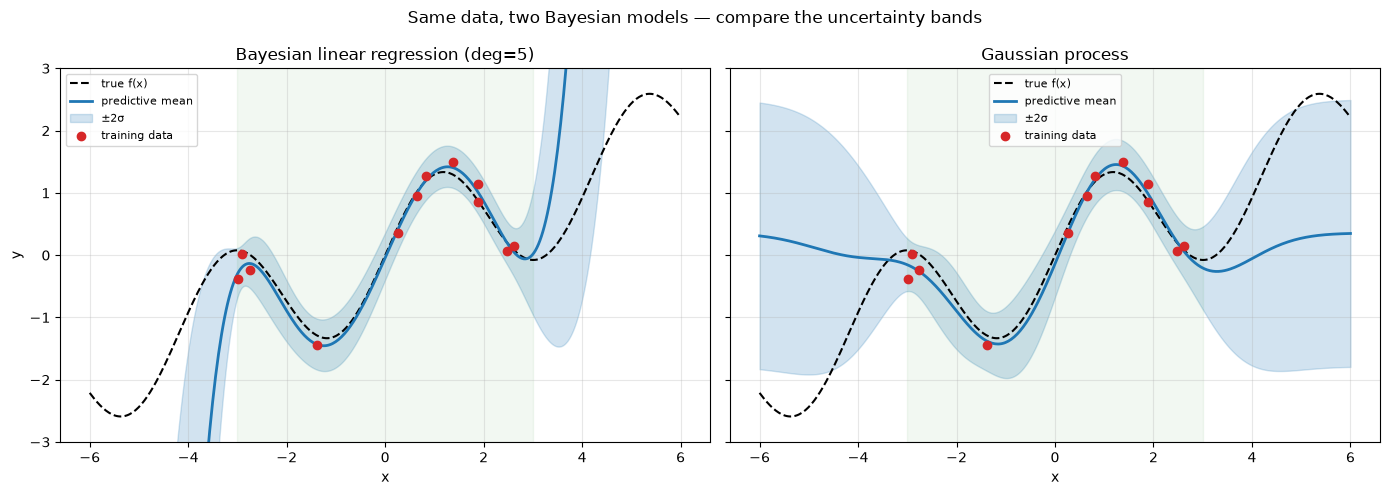

In [37]:
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

rng = np.random.default_rng(0)
def true_f(x):
    return np.sin(1.5 * x) + 0.3 * x

X_train = np.sort(rng.uniform(-3, 3, 12)).reshape(-1, 1)
y_train = true_f(X_train).ravel() + rng.normal(0, 0.2, len(X_train))
X_test = np.linspace(-6, 6, 400).reshape(-1, 1)   # extends beyond training

degree = 5   # TRY 1, 3, 5, 9
blr = make_pipeline(PolynomialFeatures(degree), BayesianRidge())
blr.fit(X_train, y_train)
blr_mean, blr_std = blr.predict(X_test, return_std=True)

kernel = ConstantKernel(1.0) * RBF(length_scale=1.0) + WhiteKernel(0.04)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
gp.fit(X_train, y_train)
gp_mean, gp_std = gp.predict(X_test, return_std=True)

xt = X_test.ravel()
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, name, mean, std in [
    (axes[0], f"Bayesian linear regression (deg={degree})", blr_mean, blr_std),
    (axes[1], "Gaussian process", gp_mean, gp_std)]:
    ax.plot(xt, true_f(xt), "k--", lw=1.5, label="true f(x)")
    ax.plot(xt, mean, "C0", lw=2, label="predictive mean")
    ax.fill_between(xt, mean - 2 * std, mean + 2 * std, color="C0", alpha=0.2, label="±2σ")
    ax.scatter(X_train, y_train, c="C3", zorder=5, label="training data")
    ax.axvspan(-3, 3, color="green", alpha=0.05)
    ax.set_title(name); ax.set_xlabel("x"); ax.grid(alpha=0.3); ax.legend(loc="best", fontsize=8)
axes[0].set_ylabel("y")
axes[0].set_ylim(-3, 3)
fig.suptitle("Same data, two Bayesian models — compare the uncertainty bands")
plt.tight_layout(); plt.show()

**Questions:** (1) means/bands agree inside the data? (2) extrapolation outside [-3, 3]? (3) vary polynomial `degree`. (4) vary GP `length_scale`. (5) why is GP the safer BO default? *Answers in the solutions notebook.*

<!-- teach -->

**Teaches:** what the three RBF knobs (ℓ, σ², σ²ₙ) do. **Shows:** small ℓ overfits/wiggles, large ℓ oversmooths; σ² scales amplitude; σ²ₙ controls interpolation vs. smoothing; then the auto-tuned fit.

## 0d. Exercise — the effect of RBF kernel hyperparameters

scikit-learn only. Sweep each RBF knob with values FIXED (no auto-tuning)
so its isolated effect is visible. Reuses true_f / X_train / y_train /
X_test / xt from 0c.

In [38]:
def fit_fixed_rbf(length_scale, signal_var=1.0, noise_var=0.04):
    """Fit a GP with FIXED RBF hyperparameters (no marginal-likelihood tuning)."""
    kernel = (ConstantKernel(signal_var, constant_value_bounds="fixed")
              * RBF(length_scale, length_scale_bounds="fixed")
              + WhiteKernel(noise_var, noise_level_bounds="fixed"))
    gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True, optimizer=None)
    gp.fit(X_train, y_train)
    mean, std = gp.predict(X_test, return_std=True)
    return mean, std


def panel(ax, title, mean, std):
    ax.plot(xt, true_f(xt), "k--", lw=1.2, label="true f(x)")
    ax.plot(xt, mean, "C0", lw=2, label="GP mean")
    ax.fill_between(xt, mean - 2 * std, mean + 2 * std, color="C0", alpha=0.2, label="±2σ")
    ax.scatter(X_train, y_train, c="C3", s=25, zorder=5, label="data")
    ax.axvspan(-3, 3, color="green", alpha=0.05)
    ax.set_title(title, fontsize=10); ax.set_xlabel("x"); ax.grid(alpha=0.3)

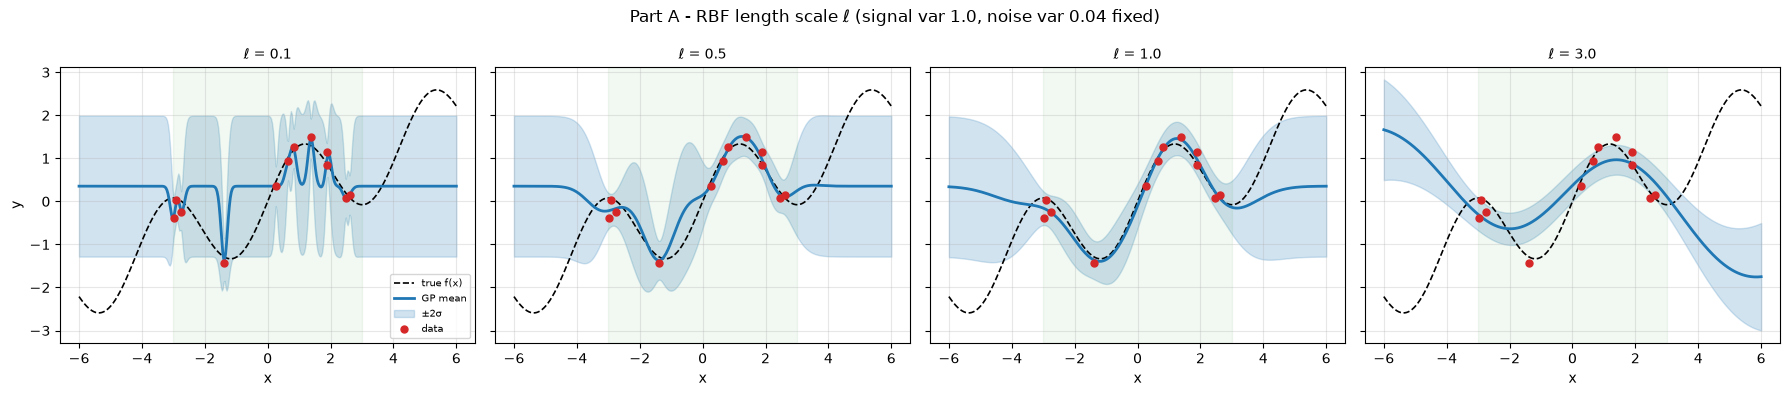

In [39]:
# Part A - length scale (the most important knob)
length_scales = [0.1, 0.5, 1.0, 3.0]
fig, axes = plt.subplots(1, len(length_scales), figsize=(18, 4), sharey=True)
for ax, ls in zip(axes, length_scales):
    mean, std = fit_fixed_rbf(length_scale=ls)
    panel(ax, f"ℓ = {ls}", mean, std)
axes[0].set_ylabel("y"); axes[0].legend(loc="best", fontsize=7)
fig.suptitle("Part A - RBF length scale ℓ (signal var 1.0, noise var 0.04 fixed)")
plt.tight_layout(); plt.show()

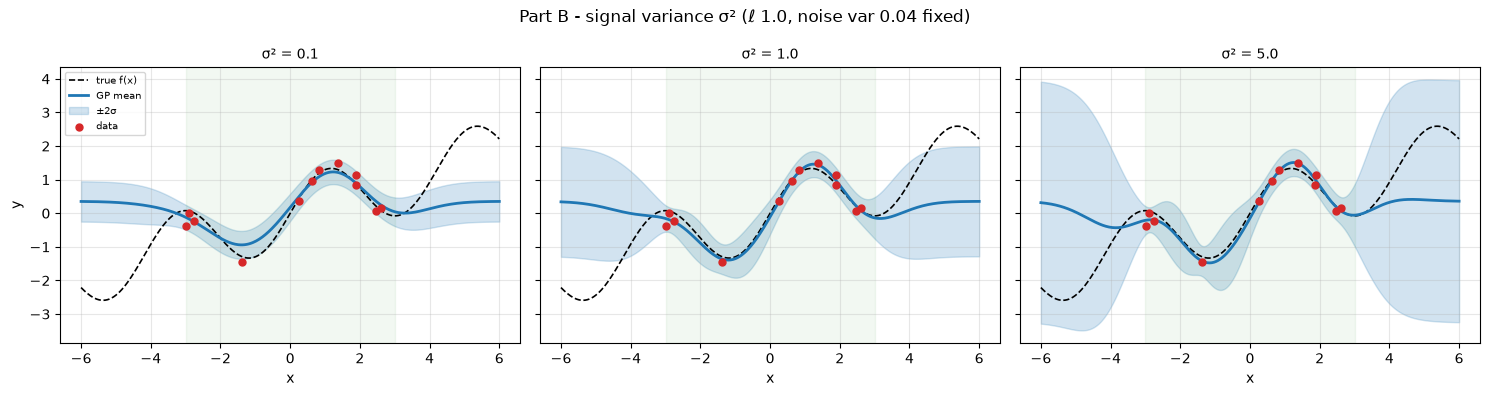

In [40]:
# Part B - signal variance
signal_vars = [0.1, 1.0, 5.0]
fig, axes = plt.subplots(1, len(signal_vars), figsize=(15, 4), sharey=True)
for ax, sv in zip(axes, signal_vars):
    mean, std = fit_fixed_rbf(length_scale=1.0, signal_var=sv)
    panel(ax, f"σ² = {sv}", mean, std)
axes[0].set_ylabel("y"); axes[0].legend(loc="best", fontsize=7)
fig.suptitle("Part B - signal variance σ² (ℓ 1.0, noise var 0.04 fixed)")
plt.tight_layout(); plt.show()

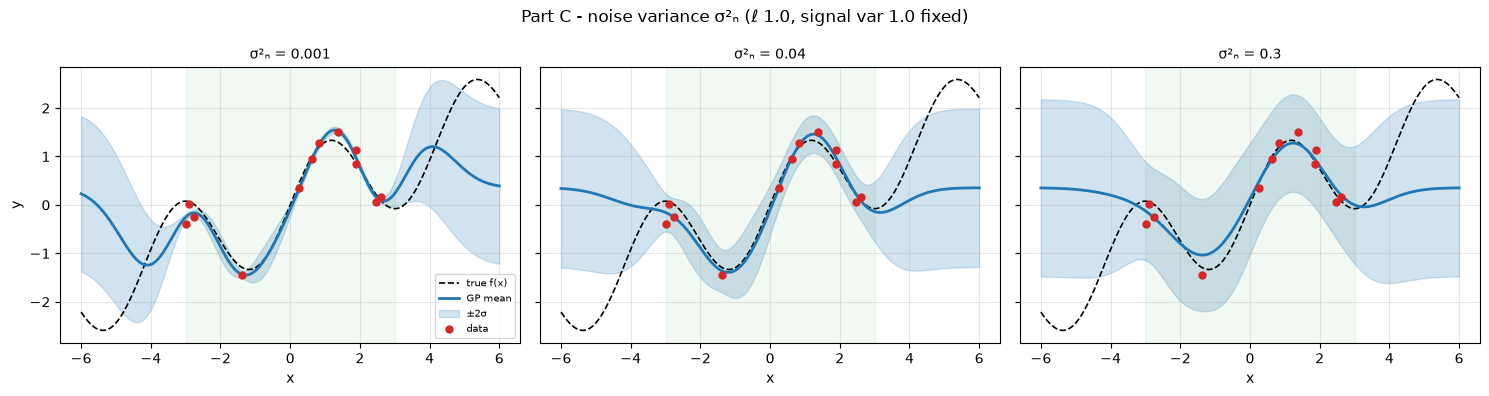

In [41]:
# Part C - noise variance
noise_vars = [0.001, 0.04, 0.3]
fig, axes = plt.subplots(1, len(noise_vars), figsize=(15, 4), sharey=True)
for ax, nv in zip(axes, noise_vars):
    mean, std = fit_fixed_rbf(length_scale=1.0, noise_var=nv)
    panel(ax, f"σ²ₙ = {nv}", mean, std)
axes[0].set_ylabel("y"); axes[0].legend(loc="best", fontsize=7)
fig.suptitle("Part C - noise variance σ²ₙ (ℓ 1.0, signal var 1.0 fixed)")
plt.tight_layout(); plt.show()

**Questions:** (1) which ℓ overfits vs. underfits? (2) what does σ² change? (3) is small or large σ²ₙ right under noise? (4) compare your best eyeball fit with sklearn's auto-tuned kernel below.

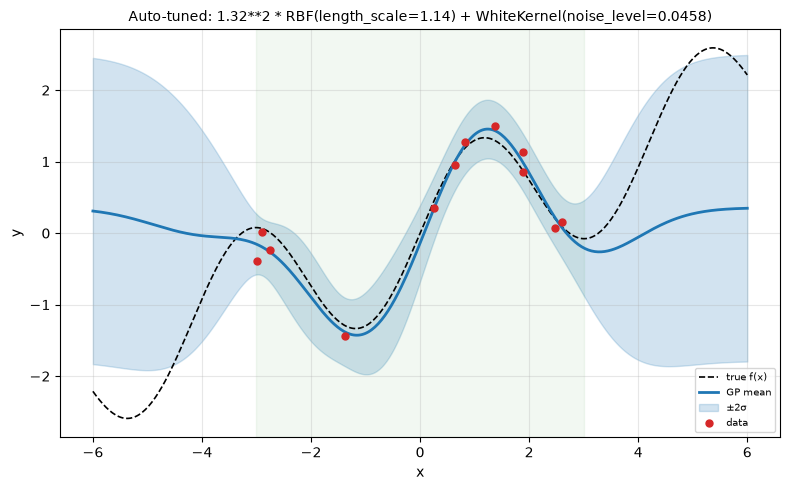

Learned kernel: 1.32**2 * RBF(length_scale=1.14) + WhiteKernel(noise_level=0.0458)


In [42]:
# Compare with the auto-tuned (marginal-likelihood optimized) kernel.
kernel = ConstantKernel(1.0) * RBF(1.0) + WhiteKernel(0.04)
gp_auto = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
gp_auto.fit(X_train, y_train)
mean, std = gp_auto.predict(X_test, return_std=True)
fig, ax = plt.subplots(figsize=(8, 5))
panel(ax, f"Auto-tuned: {gp_auto.kernel_}", mean, std)
ax.set_ylabel("y"); ax.legend(loc="best", fontsize=7)
plt.tight_layout(); plt.show()
print("Learned kernel:", gp_auto.kernel_)

<!-- teach -->

**Teaches:** the end-to-end BO loop on a known minimum (x = 2). **Shows:** GP fit after optimization + the acquisition-driven next point.

## 1. Parabola (basic Bayesian optimization)

In [43]:
from xopt import Xopt, VOCS
from xopt.evaluator import Evaluator
from xopt.generators.bayesian import ExpectedImprovementGenerator

vocs = VOCS(variables={"x": [-5.0, 5.0]}, objectives={"f": "MINIMIZE"})

def parabola(inputs: dict) -> dict:
    x = inputs["x"]
    return {"f": (x - 2.0) ** 2 + 1.0}   # true minimum at x = 2

evaluator = Evaluator(function=parabola)
generator = ExpectedImprovementGenerator(vocs=vocs)
X = Xopt(vocs=vocs, evaluator=evaluator, generator=generator)

X.random_evaluate(3)
for i in range(10):
    X.step()

print(X.data)
best = X.data.loc[X.data["f"].idxmin()]
print("Best x:", best["x"], "  f:", best["f"])

           x          f  xopt_runtime  xopt_error
0   3.475300   3.176510  1.582899e-06       False
1   4.032580   5.131380  4.590256e-07       False
2   2.989351   1.978816  3.749738e-07       False
3   0.894231   2.222724  1.333072e-06       False
4   2.138766   1.019256  1.208973e-06       False
5  -5.000000  50.000000  8.329516e-07       False
6   1.870468   1.016779  1.250068e-06       False
7   1.934679   1.004267  8.749776e-07       False
8   1.946053   1.002910  8.749776e-07       False
9   1.955918   1.001943  1.125038e-06       False
10  1.963039   1.001366  7.499475e-07       False
11  1.969063   1.000957  7.910421e-07       False
12  1.974819   1.000634  7.919734e-07       False
Best x: 1.9748193003064978   f: 1.0006340676370544


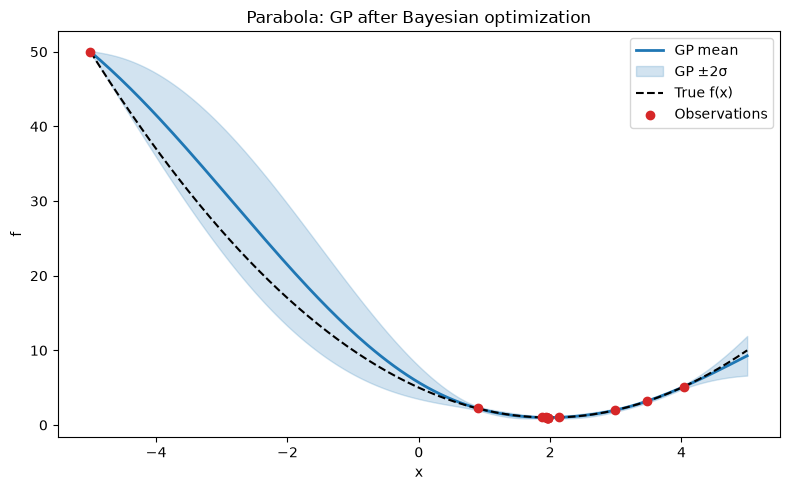

In [44]:
plot_gp_1d(X, true_func=lambda x: (x - 2.0) ** 2 + 1.0,
           title="Parabola: GP after Bayesian optimization")

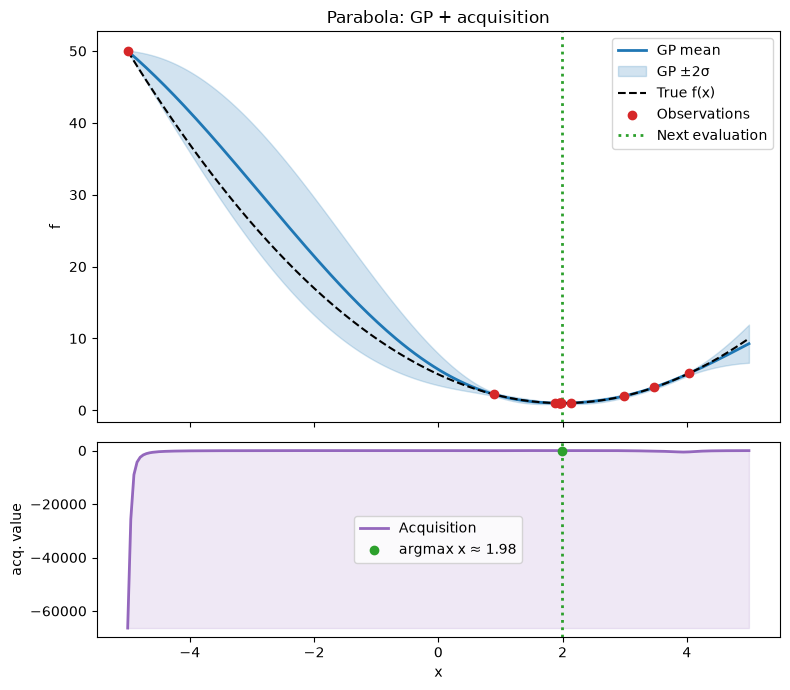

Next x ≈ 1.985


In [45]:
x_next = plot_gp_and_acqf_1d(X, true_func=lambda x: (x - 2.0) ** 2 + 1.0,
                             title="Parabola: GP + acquisition")
print("Next x ≈", round(x_next, 3))

<!-- teach -->

**Teaches:** GPs handle measurement noise via the noise term. **Shows:** points scatter around the true curve, but the GP mean stays a smooth trend; best-observed ≠ GP's estimate.

## 2. Noisy parabola

In [46]:
def noisy_parabola(inputs: dict) -> dict:
    x = inputs["x"]
    return {"f": (x - 2.0) ** 2 + 1.0 + np.random.normal(0.0, 0.5)}

vocs = VOCS(variables={"x": [-5.0, 5.0]}, objectives={"f": "MINIMIZE"})
evaluator = Evaluator(function=noisy_parabola)
generator = ExpectedImprovementGenerator(vocs=vocs)
X = Xopt(vocs=vocs, evaluator=evaluator, generator=generator)

X.random_evaluate(5)
for i in range(15):
    X.step()

best = X.data.loc[X.data["f"].idxmin()]
print("Best observed x:", best["x"], "  f:", best["f"])

Best observed x: 1.877254735312169   f: 0.15893822994551343


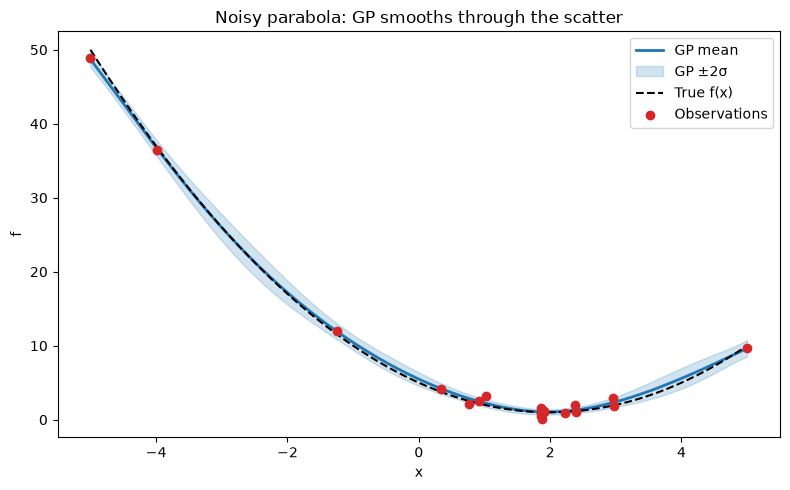

In [47]:
plot_gp_1d(X, true_func=lambda x: (x - 2.0) ** 2 + 1.0,
           title="Noisy parabola: GP smooths through the scatter")

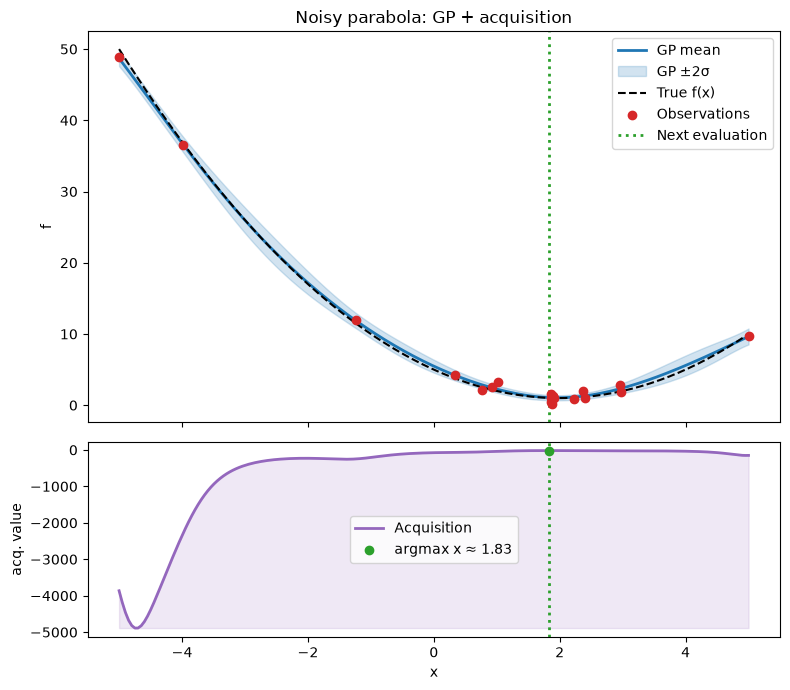

Next x ≈ 1.834


In [48]:
x_next = plot_gp_and_acqf_1d(X, true_func=lambda x: (x - 2.0) ** 2 + 1.0,
                             title="Noisy parabola: GP + acquisition")
print("Next x ≈", round(x_next, 3))

<!-- teach -->

**Teaches:** constraints reshape *where* BO samples. **Shows:** objective GP + infeasible region + the constrained acquisition peaking at the feasible boundary (x ≈ 1.5), not the true min.

## 3. Constrained parabola

In [49]:
vocs = VOCS(variables={"x": [-5.0, 5.0]}, objectives={"f": "MINIMIZE"},
            constraints={"c": ["GREATER_THAN", 0.0]})

def constrained_parabola(inputs: dict) -> dict:
    x = inputs["x"]
    return {"f": (x - 2.0) ** 2 + 1.0, "c": 1.5 - x}

evaluator = Evaluator(function=constrained_parabola)
generator = ExpectedImprovementGenerator(vocs=vocs)
X = Xopt(vocs=vocs, evaluator=evaluator, generator=generator)

X.random_evaluate(5)
for i in range(15):
    X.step()

feasible = X.data[X.data["c"] > 0.0]
best = feasible.loc[feasible["f"].idxmin()]
print("Best feasible x:", best["x"], "  f:", best["f"])

Best feasible x: 1.2698408861970625   f: 1.5331323314694911


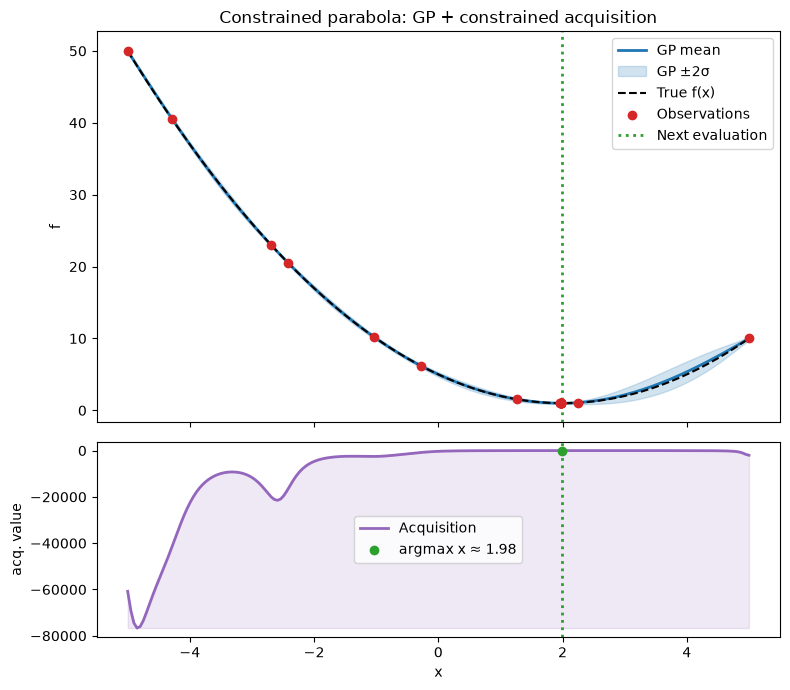

Next x ≈ 1.985


In [50]:
x_next = plot_gp_and_acqf_1d(X, obj_name="f", outcome_index=0,
                             true_func=lambda x: (x - 2.0) ** 2 + 1.0,
                             title="Constrained parabola: GP + constrained acquisition")
print("Next x ≈", round(x_next, 3))

<!-- teach -->

**Teaches:** everything generalizes past 1-D. **Shows:** acquisition as a heatmap with a red star = next point.

## 4. Two-dimensional problem + acquisition heatmap

In [51]:
vocs = VOCS(variables={"x": [-5.0, 5.0], "y": [-5.0, 5.0]},
            objectives={"f": "MINIMIZE"})

def bowl_2d(inputs: dict) -> dict:
    x, y = inputs["x"], inputs["y"]
    return {"f": (x - 1.0) ** 2 + (y + 2.0) ** 2}   # min at (1, -2)

evaluator = Evaluator(function=bowl_2d)
generator = ExpectedImprovementGenerator(vocs=vocs)
X = Xopt(vocs=vocs, evaluator=evaluator, generator=generator)

X.random_evaluate(5)
for i in range(20):
    X.step()

best = X.data.loc[X.data["f"].idxmin()]
print("Best (x, y):", best["x"], best["y"], "  f:", best["f"])

Best (x, y): 0.9966109938950527 -1.9939048749785406   f: 4.863591140659014e-05


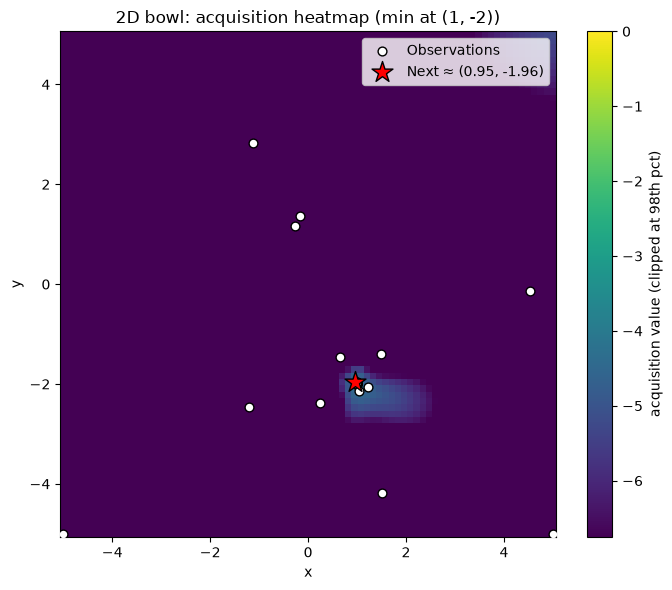

(0.9493670886075947, -1.962025316455696)

In [52]:
def plot_acqf_heatmap_2d(X, var_x="x", var_y="y", n_grid=80, title=None):
    generator = X.generator
    model = generator.train_model()
    acqf = generator.get_acquisition(model)
    x_lo, x_hi = X.vocs.variables[var_x]
    y_lo, y_hi = X.vocs.variables[var_y]
    xs = torch.linspace(x_lo, x_hi, n_grid, dtype=torch.double)
    ys = torch.linspace(y_lo, y_hi, n_grid, dtype=torch.double)
    XX, YY = torch.meshgrid(xs, ys, indexing="ij")
    order = X.vocs.variable_names
    coord_lookup = {var_x: XX.reshape(-1), var_y: YY.reshape(-1)}
    candidates = torch.stack([coord_lookup[n] for n in order], dim=-1)
    with torch.no_grad():
        acqf_values = acqf(candidates.unsqueeze(1)).numpy()
    acqf_grid = acqf_values.reshape(n_grid, n_grid)
    flat_best = int(np.argmax(acqf_values))
    x_next = candidates[flat_best, order.index(var_x)].item()
    y_next = candidates[flat_best, order.index(var_y)].item()

    # Clip at 98th percentile so outlier spikes don't flatten the colormap
    vmax = float(np.percentile(acqf_values, 98))
    vmin = float(max(0.0, acqf_values.min()))

    plt.figure(figsize=(7, 6))
    mesh = plt.pcolormesh(xs.numpy(), ys.numpy(), acqf_grid.T,
                          shading="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    plt.colorbar(mesh, label="acquisition value (clipped at 98th pct)")
    plt.scatter(X.data[var_x], X.data[var_y], c="white", edgecolors="black",
                s=40, zorder=5, label="Observations")
    plt.scatter([x_next], [y_next], c="red", marker="*", s=250, edgecolors="black",
                zorder=6, label=f"Next ≈ ({x_next:.2f}, {y_next:.2f})")
    plt.xlabel(var_x); plt.ylabel(var_y); plt.title(title or "2D acquisition heatmap")
    plt.legend(loc="best"); plt.tight_layout(); plt.show()
    return x_next, y_next

plot_acqf_heatmap_2d(X, title="2D bowl: acquisition heatmap (min at (1, -2))")

<!-- teach -->

**Teaches:** β in UCB/LCB *is* the explore/exploit dial. **Shows:** one GP, several β; the next-point marker migrates from the current best (exploit) to the uncertain gap (explore). Twin-axis sweep quantifies it.

## P5 — Exploration vs. exploitation (UCB/LCB β dial)

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel

rng = np.random.default_rng(1)
def true_f(x):
    return np.sin(3 * x) + 0.5 * (x - 1.0) ** 2

X_train = np.array([-1.6, -1.0, -0.2, 0.4, 1.1]).reshape(-1, 1)
y_train = true_f(X_train).ravel() + rng.normal(0, 0.03, len(X_train))
X_test = np.linspace(-2, 2.5, 500).reshape(-1, 1)
xt = X_test.ravel()

kernel = ConstantKernel(1.0) * RBF(0.5) + WhiteKernel(0.01)
gp = GaussianProcessRegressor(kernel=kernel, normalize_y=True)
gp.fit(X_train, y_train)
mean, std = gp.predict(X_test, return_std=True)
best_y = y_train.min()

/Users/rshara01/miniforge3/envs/bo_xopt/lib/python3.14/site-packages/sklearn/gaussian_process/kernels.py:445: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


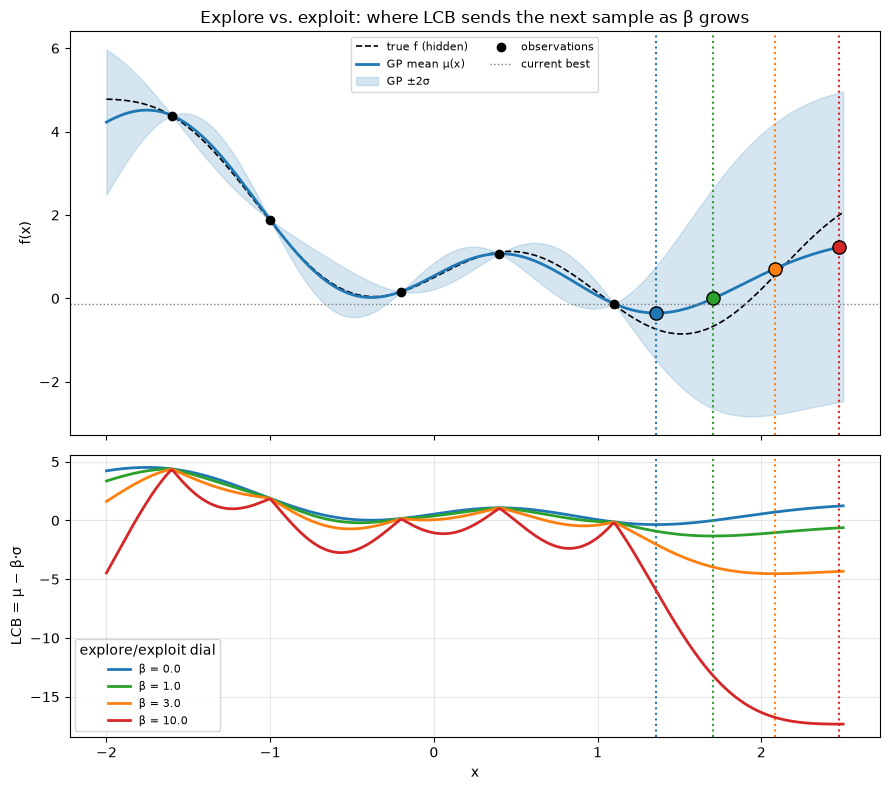

In [54]:
betas = [0.0, 1.0, 3.0, 10.0]
colors = ["C0", "C2", "C1", "C3"]
fig, (ax_gp, ax_acq) = plt.subplots(2, 1, figsize=(9, 8), sharex=True,
                                    gridspec_kw={"height_ratios": [2, 1.4]})
ax_gp.plot(xt, true_f(xt), "k--", lw=1.2, label="true f (hidden)")
ax_gp.plot(xt, mean, "C0", lw=2, label="GP mean μ(x)")
ax_gp.fill_between(xt, mean - 2 * std, mean + 2 * std, color="C0", alpha=0.18, label="GP ±2σ")
ax_gp.scatter(X_train, y_train, c="k", zorder=6, label="observations")
ax_gp.axhline(best_y, color="gray", ls=":", lw=1, label="current best")
for beta, c in zip(betas, colors):
    lcb = mean - beta * std
    x_next = xt[np.argmin(lcb)]
    ax_acq.plot(xt, lcb, color=c, lw=2, label=f"β = {beta}")
    ax_acq.axvline(x_next, color=c, ls=":", lw=1.5)
    ax_gp.axvline(x_next, color=c, ls=":", lw=1.5)
    ax_gp.scatter([x_next], [mean[np.argmin(lcb)]], color=c, s=90, zorder=7, edgecolors="k")
ax_gp.set_ylabel("f(x)")
ax_gp.set_title("Explore vs. exploit: where LCB sends the next sample as β grows")
ax_gp.legend(loc="upper center", fontsize=8, ncol=2)
ax_acq.set_xlabel("x"); ax_acq.set_ylabel("LCB = μ − β·σ")
ax_acq.legend(loc="best", fontsize=8, title="explore/exploit dial"); ax_acq.grid(alpha=0.3)
plt.tight_layout(); plt.show()

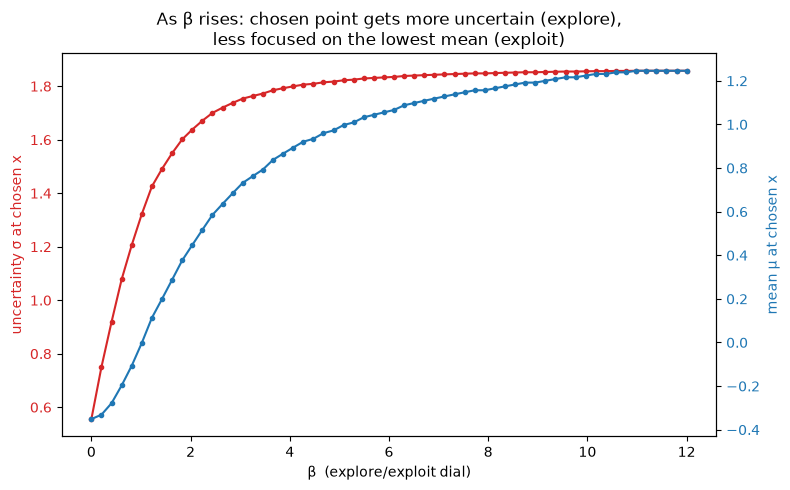

In [55]:
# Optional: quantify the trade-off across a beta sweep.
betas_fine = np.linspace(0, 12, 60)
chosen_mean, chosen_std = [], []
for beta in betas_fine:
    idx = np.argmin(mean - beta * std)
    chosen_mean.append(mean[idx]); chosen_std.append(std[idx])
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(betas_fine, chosen_std, "C3-o", ms=3, label="σ at chosen point (exploration)")
ax1.set_xlabel("β  (explore/exploit dial)")
ax1.set_ylabel("uncertainty σ at chosen x", color="C3"); ax1.tick_params(axis="y", labelcolor="C3")
ax2 = ax1.twinx()
ax2.plot(betas_fine, chosen_mean, "C0-o", ms=3, label="μ at chosen point (exploitation)")
ax2.set_ylabel("mean μ at chosen x", color="C0"); ax2.tick_params(axis="y", labelcolor="C0")
ax1.set_title("As β rises: chosen point gets more uncertain (explore),\nless focused on the lowest mean (exploit)")
fig.tight_layout(); plt.show()

**Questions:** (1) at which β does the pick jump to the uncertain gap? (2) what fails after many iterations with β = 0? (3) how does EI balance explore/exploit with no β?

<!-- teach -->

**Teaches:** run BO on real tabular data (warm-start + closed-loop). **Shows:** the full workflow — explore data, suggest, converge, inspect.

## 5. Real dataset — environmental.csv into XOpt

Inputs: `G:HUMID` (humidity), `G:SOLRAD` (solar radiation).
Objective: `G:OUTTMP` (outdoor temperature, MAXIMIZE).
Three channels with separate timestamp columns at different sample rates;
Step 0 aligns them onto a common 15 s grid.

## Step 0 — Load and timestamp-align environmental.csv

Three channels sampled at different rates:
- `G:OUTTMP` — ~15 s cadence (coarsest)
- `G:HUMID`, `G:SOLRAD` — ~1 s cadence

Strategy: use `pd.merge_asof` to snap HUMID and SOLRAD onto OUTTMP’s 15 s timestamps
(nearest match within ±8 s tolerance), then drop any rows that are still missing.

In [56]:
import pandas as pd

raw = pd.read_csv("environmental.csv")

# Split into three single-channel DataFrames, each sorted by its own timestamp
outtmp = raw[["tstamp_G:OUTTMP", "G:OUTTMP"]].dropna().rename(columns={"tstamp_G:OUTTMP": "t"}).sort_values("t").reset_index(drop=True)
humid  = raw[["tstamp_G:HUMID",  "G:HUMID" ]].dropna().rename(columns={"tstamp_G:HUMID":  "t"}).sort_values("t").reset_index(drop=True)
solrad = raw[["tstamp_G:SOLRAD", "G:SOLRAD"]].dropna().rename(columns={"tstamp_G:SOLRAD": "t"}).sort_values("t").reset_index(drop=True)

# Anchor on OUTTMP's 15 s grid (coarsest), nearest-neighbour match within ±8 s
TOLERANCE = 8  # seconds

df = pd.merge_asof(outtmp, humid,  on="t", direction="nearest", tolerance=TOLERANCE)
df = pd.merge_asof(df,     solrad, on="t", direction="nearest", tolerance=TOLERANCE)

before = len(df)
df = df.dropna().reset_index(drop=True)

print(f"Aligned rows: {len(df)}  (dropped {before - len(df)} with no match within ±{TOLERANCE} s)")
print(f"Time span: {df['t'].min():.1f} – {df['t'].max():.1f}  ({(df['t'].max()-df['t'].min())/3600:.2f} h)")
print(df[["G:OUTTMP", "G:HUMID", "G:SOLRAD"]].describe().round(3))

Aligned rows: 5760  (dropped 0 with no match within ±8 s)
Time span: 1783876355.3 – 1783962740.3  (24.00 h)
       G:OUTTMP   G:HUMID  G:SOLRAD
count  5760.000  5760.000  5760.000
mean     74.758    67.567   155.709
std       9.146    21.552   175.473
min      60.660    36.470     0.000
25%      64.560    46.983     0.000
50%      75.760    64.375    86.000
75%      84.360    92.575   312.800
max      86.540   100.000   533.700


### Step 1 — Inspect the data and build a matching VOCS

In [57]:
input_cols  = ["G:HUMID", "G:SOLRAD"]
target_col  = "G:OUTTMP"

print(df[input_cols + [target_col]].describe().round(3))

variables = {c: [float(df[c].min()), float(df[c].max())] for c in input_cols}
vocs = VOCS(variables=variables, objectives={target_col: "MAXIMIZE"})
print(vocs)

        G:HUMID  G:SOLRAD  G:OUTTMP
count  5760.000  5760.000  5760.000
mean     67.567   155.709    74.758
std      21.552   175.473     9.146
min      36.470     0.000    60.660
25%      46.983     0.000    64.560
50%      64.375    86.000    75.760
75%      92.575   312.800    84.360
max     100.000   533.700    86.540
variables={'G:HUMID': [36.47000122, 100.0], 'G:SOLRAD': [0.0, 533.70001221]} constraints={} objectives={'G:OUTTMP': 'MAXIMIZE'} constants={} observables=[]


### Step 1b (plot) — Explore the raw data before optimizing

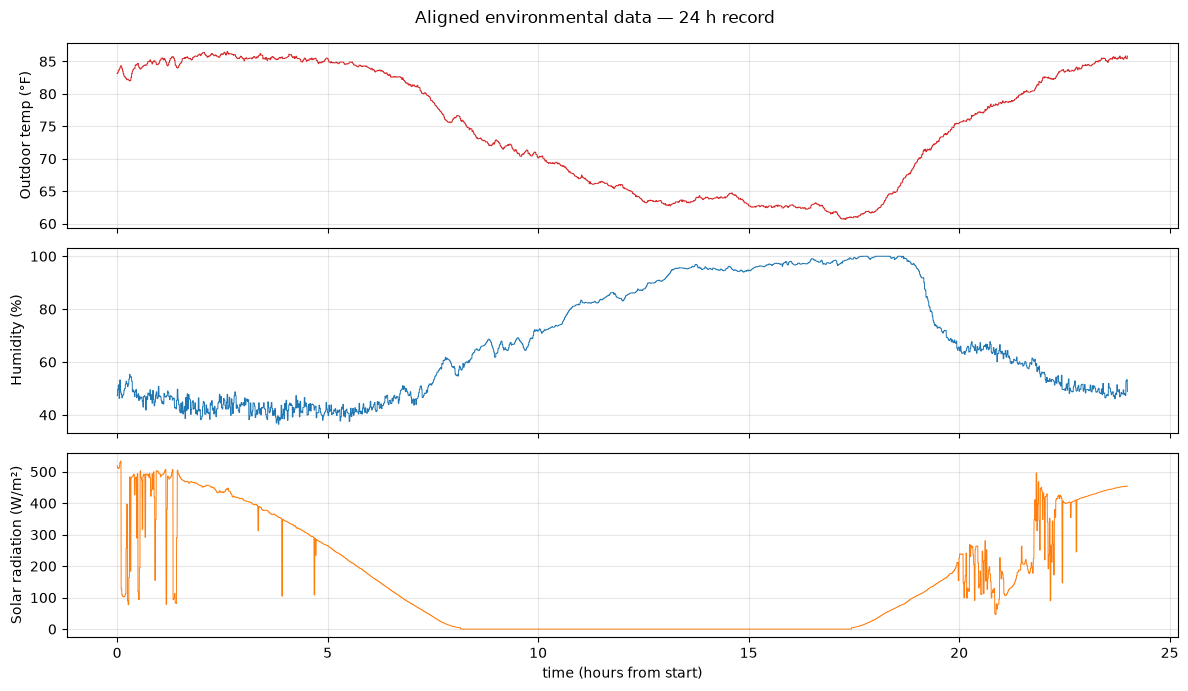

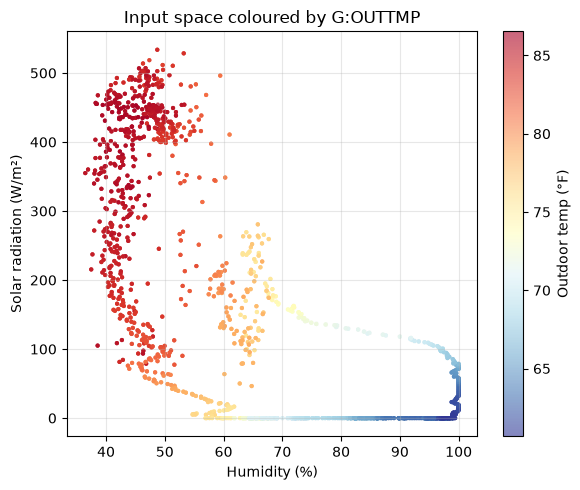

In [58]:
t_h = (df["t"] - df["t"].iloc[0]) / 3600  # hours from start

all_cols = [target_col] + input_cols  # OUTTMP, HUMID, SOLRAD
labels = {"G:OUTTMP": "Outdoor temp (°F)", "G:HUMID": "Humidity (%)", "G:SOLRAD": "Solar radiation (W/m²)"}
colors  = ["C3", "C0", "C1"]

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
for ax, col, color in zip(axes, all_cols, colors):
    ax.plot(t_h, df[col], lw=0.7, color=color)
    ax.set_ylabel(labels[col]); ax.grid(alpha=0.3)
axes[-1].set_xlabel("time (hours from start)")
fig.suptitle("Aligned environmental data — 24 h record")
plt.tight_layout(); plt.show()

# With only 2 inputs there is one pair: HUMID vs SOLRAD, coloured by OUTTMP
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(df[input_cols[0]], df[input_cols[1]],
                c=df[target_col], cmap="RdYlBu_r", s=4, alpha=0.6)
fig.colorbar(sc, ax=ax, label=labels[target_col])
ax.set_xlabel(labels[input_cols[0]]); ax.set_ylabel(labels[input_cols[1]])
ax.set_title(f"Input space coloured by {target_col}"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Step 2 (Workflow A) — Warm-start XOpt and ask for a suggestion

In [59]:
WARMSTART_N = 100  # use only the first N points to keep BO fast

def not_implemented_eval(inputs: dict) -> dict:
    raise RuntimeError("Run the suggested point, then append the result and repeat.")

evaluator = Evaluator(function=not_implemented_eval)
generator = ExpectedImprovementGenerator(vocs=vocs)
X = Xopt(vocs=vocs, evaluator=evaluator, generator=generator)
X.add_data(df[input_cols + [target_col]].head(WARMSTART_N))

candidates = X.generator.generate(1)
print("Suggested next experiment:", candidates[0])

Suggested next experiment: {'G:HUMID': 48.60421468739876, 'G:SOLRAD': 533.70001221}


### Step 2b (plot) — Show the suggested point against the data

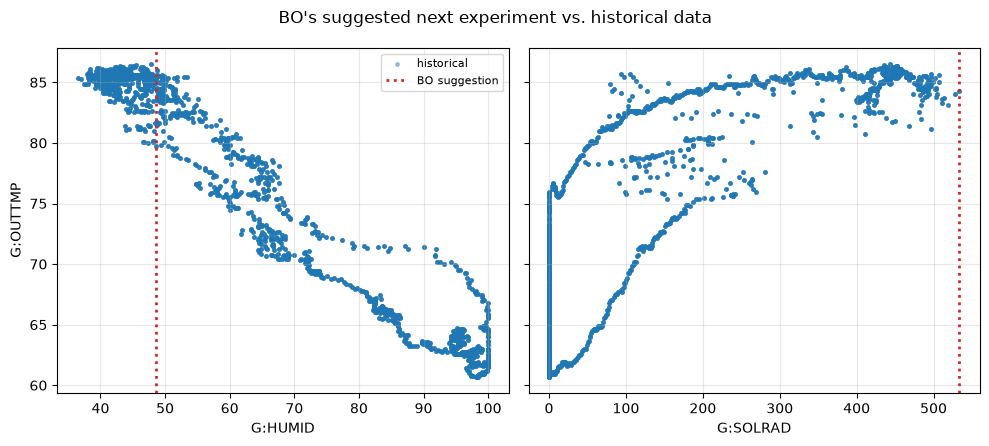

Suggested settings:
  G:HUMID: 48.604
  G:SOLRAD: 533.700


In [60]:
suggestion = candidates[0]

fig, axes = plt.subplots(1, len(input_cols), figsize=(10, 4.5), sharey=True)
for ax, col in zip(axes, input_cols):
    ax.scatter(df[col], df[target_col], c="C0", s=6, alpha=0.4, label="historical")
    ax.axvline(suggestion[col], color="C3", ls=":", lw=2, label="BO suggestion")
    ax.set_xlabel(col); ax.grid(alpha=0.3)
axes[0].set_ylabel(target_col)
axes[0].legend(loc="best", fontsize=8)
fig.suptitle("BO's suggested next experiment vs. historical data")
plt.tight_layout(); plt.show()

print("Suggested settings:")
for col in input_cols:
    print(f"  {col}: {suggestion[col]:.3f}")

### Step 2c (plot) — Human-in-the-loop: append a result, re-ask

Re-run this cell repeatedly; each run simulates one lab experiment.

In [61]:
measured = {**suggestion, target_col: 85.0}
X.add_data(pd.DataFrame([measured]))

next_candidates = X.generator.generate(1)
print("Next suggestion after 1 new result:", next_candidates[0])
print(f"Experiments so far: {len(X.data)}   Best {target_col}: {X.data[target_col].max():.3f}")

Next suggestion after 1 new result: {'G:HUMID': 46.80118056479896, 'G:SOLRAD': 251.21556636049564}
Experiments so far: 101   Best G:OUTTMP: 85.000


### Step 3 (Workflow B) — Closed-loop against a surrogate

Nearest-neighbor surrogate stands in for a live experiment. Demo only.

In [62]:
from scipy.interpolate import NearestNDInterpolator

WARMSTART_N = 100  # warm-start BO with this many historical points

# Surrogate trained on ALL data — not reused by Xopt, just called in surrogate()
points        = df[input_cols].to_numpy()
outtmp_interp = NearestNDInterpolator(points, df[target_col].to_numpy())

def surrogate(inputs: dict) -> dict:
    x = np.array([[inputs[c] for c in input_cols]])
    return {target_col: float(outtmp_interp(x)[0])}

variables = {c: [float(df[c].min()), float(df[c].max())] for c in input_cols}
vocs_loop = VOCS(variables=variables, objectives={target_col: "MAXIMIZE"})

evaluator = Evaluator(function=surrogate)
generator = ExpectedImprovementGenerator(vocs=vocs_loop)
X = Xopt(vocs=vocs_loop, evaluator=evaluator, generator=generator)
X.add_data(df[input_cols + [target_col]].head(WARMSTART_N))  # only first N points

n_warmstart = len(X.data)
for i in range(20):
    X.step()

best = X.data.loc[X.data[target_col].idxmax()]
print("Best settings found:")
print(best[input_cols + [target_col]])

Best settings found:
G:HUMID      46.691444
G:SOLRAD    433.314157
G:OUTTMP     86.290001
Name: 100, dtype: object


### Step 3b (plot) — Convergence: best observed temperature vs. iteration

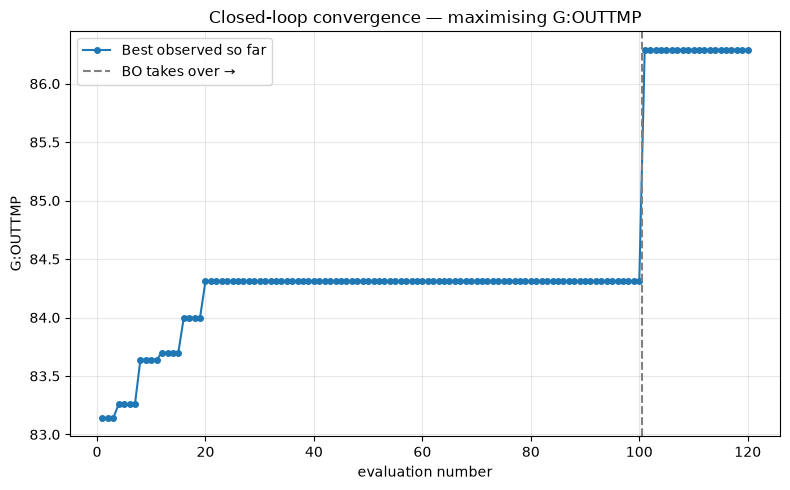

In [63]:
data = X.data.reset_index(drop=True)
running_best = data[target_col].cummax()
iterations   = np.arange(1, len(data) + 1)

plt.figure(figsize=(8, 5))
plt.plot(iterations, running_best, "C0-o", ms=4, label="Best observed so far")
plt.axvline(n_warmstart + 0.5, color="gray", ls="--", label="BO takes over →")
plt.xlabel("evaluation number"); plt.ylabel(target_col)
plt.title(f"Closed-loop convergence — maximising {target_col}")
plt.legend(loc="best"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Step 3c (plot) — Where did BO sample?

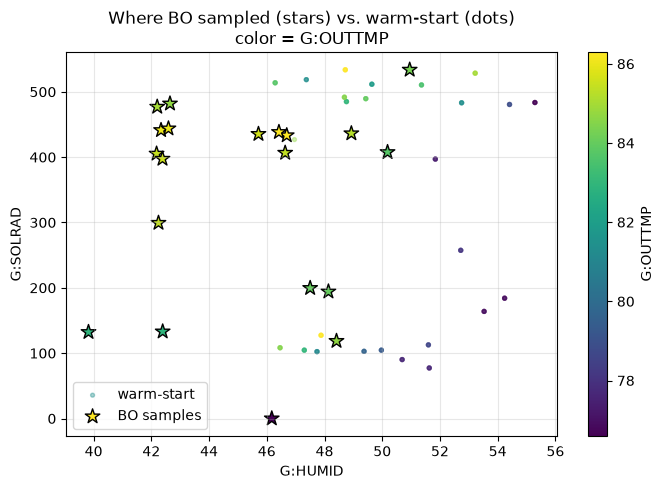

In [64]:
data  = X.data.reset_index(drop=True)
is_bo = np.arange(len(data)) >= n_warmstart

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(data.loc[~is_bo, input_cols[0]], data.loc[~is_bo, input_cols[1]],
           c=data.loc[~is_bo, target_col], cmap="viridis", s=8, alpha=0.4, label="warm-start")
sc = ax.scatter(data.loc[is_bo, input_cols[0]], data.loc[is_bo, input_cols[1]],
                c=data.loc[is_bo, target_col], cmap="viridis", s=120,
                marker="*", edgecolors="black", label="BO samples")
plt.colorbar(sc, ax=ax, label=target_col)
ax.set_xlabel(input_cols[0]); ax.set_ylabel(input_cols[1])
ax.set_title(f"Where BO sampled (stars) vs. warm-start (dots)\ncolor = {target_col}")
ax.legend(loc="best"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Step 3d (plot) — 2-D GP-predicted surface over the input space

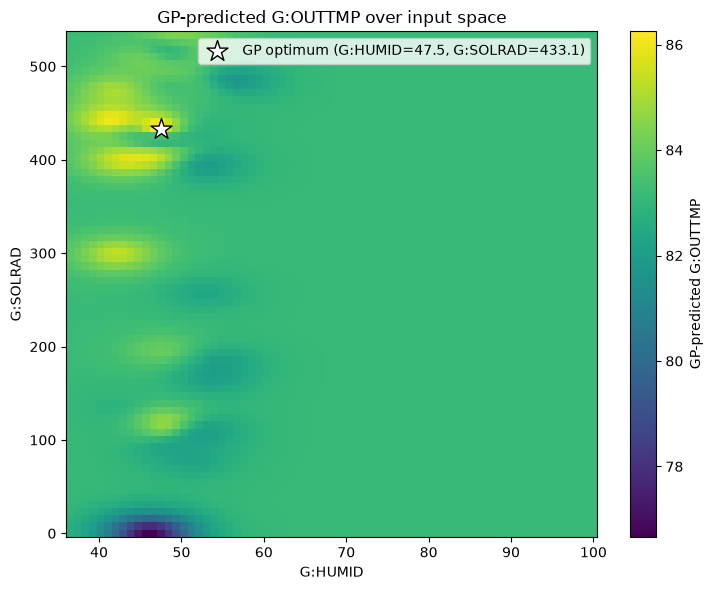

In [65]:
model = X.generator.train_model()
order = X.vocs.variable_names   # ['G:HUMID', 'G:SOLRAD']

n_grid = 70
xs = torch.linspace(*X.vocs.variables[order[0]], n_grid, dtype=torch.double)
ys = torch.linspace(*X.vocs.variables[order[1]], n_grid, dtype=torch.double)
XX, YY = torch.meshgrid(xs, ys, indexing="ij")
candidates = torch.stack([XX.reshape(-1), YY.reshape(-1)], dim=-1)

with torch.no_grad():
    mu = model.posterior(candidates).mean.squeeze(-1).reshape(n_grid, n_grid).numpy()

best_idx = int(mu.argmax())
bx = xs[best_idx // n_grid].item()
by = ys[best_idx  % n_grid].item()

plt.figure(figsize=(7.5, 6))
mesh = plt.pcolormesh(xs.numpy(), ys.numpy(), mu.T, shading="auto", cmap="viridis")
plt.colorbar(mesh, label=f"GP-predicted {target_col}")
plt.scatter([bx], [by], c="white", marker="*", s=250, edgecolors="black",
            zorder=6, label=f"GP optimum ({order[0]}={bx:.1f}, {order[1]}={by:.1f})")
plt.xlabel(order[0]); plt.ylabel(order[1])
plt.title(f"GP-predicted {target_col} over input space")
plt.legend(loc="best"); plt.tight_layout(); plt.show()

## 6 Multi-objective BO with a Pareto front
So far every example had one objective — even the constrained ones - as a constraint is a rule to obey, not a second goal. Now we consider two competing objectives with no single winner.
Two competing objectives → a **Pareto front** of compromises. Variant A runs real MOBO in XOpt; Variant B is a pure-numpy fallback that produces the same figure.

In [66]:
import numpy as np
import matplotlib.pyplot as plt


def pareto_mask(objs):
    """Boolean mask of non-dominated rows for MINIMIZATION."""
    objs = np.asarray(objs, dtype=float)
    n = len(objs)
    is_pareto = np.ones(n, dtype=bool)
    for i in range(n):
        if not is_pareto[i]:
            continue
        dominated = np.all(objs <= objs[i], axis=1) & np.any(objs < objs[i], axis=1)
        dominated[i] = False
        if dominated.any():
            is_pareto[i] = False
    return is_pareto


def plot_pareto_2d(objs, mask=None, title=None, obj_names=("f1", "f2")):
    objs = np.asarray(objs, dtype=float)
    if mask is None:
        mask = pareto_mask(objs)
    plt.figure(figsize=(6.5, 6))
    plt.scatter(objs[~mask, 0], objs[~mask, 1], c="C7", alpha=0.5, s=30, label="dominated")
    front = objs[mask]
    order = np.argsort(front[:, 0]); front = front[order]
    plt.plot(front[:, 0], front[:, 1], "C3-o", lw=2, ms=7, label="Pareto front")
    plt.xlabel(f"{obj_names[0]}  (minimize)"); plt.ylabel(f"{obj_names[1]}  (minimize)")
    plt.title(title or "Objective space: dominated points vs. Pareto front")
    plt.legend(loc="best"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
    return mask

### Variant A — real MOBO in XOpt

MOBO generator name/args vary by XOpt version; check `xopt.generators.bayesian`. If unavailable, use Variant B.

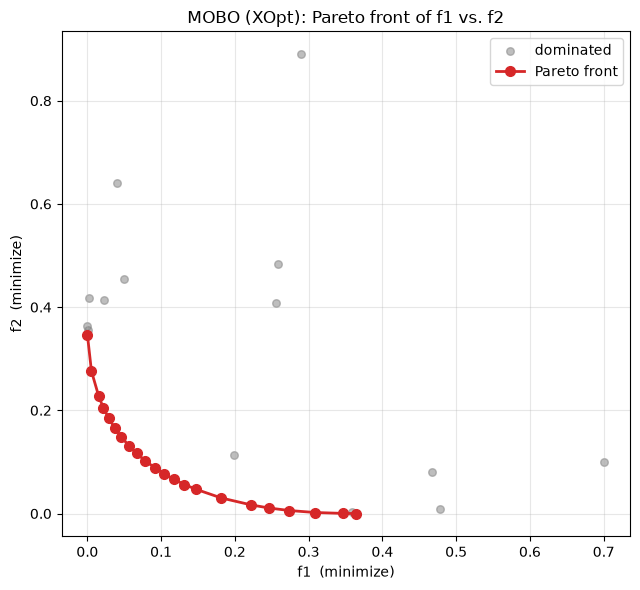

Pareto-optimal points found: 22


In [67]:
from xopt import Xopt, VOCS
from xopt.evaluator import Evaluator
from xopt.generators.bayesian import MOBOGenerator

vocs = VOCS(variables={"x": [0.0, 1.0], "y": [0.0, 1.0]},
            objectives={"f1": "MINIMIZE", "f2": "MINIMIZE"})

def two_bowls(inputs: dict) -> dict:
    x, y = inputs["x"], inputs["y"]
    return {"f1": (x - 0.2) ** 2 + (y - 0.5) ** 2,
            "f2": (x - 0.8) ** 2 + (y - 0.5) ** 2}

evaluator = Evaluator(function=two_bowls)
generator = MOBOGenerator(vocs=vocs, reference_point={"f1": 1.5, "f2": 1.5})
X = Xopt(vocs=vocs, evaluator=evaluator, generator=generator)

X.random_evaluate(6)
for i in range(30):
    X.step()

objs = X.data[["f1", "f2"]].to_numpy()
plot_pareto_2d(objs, title="MOBO (XOpt): Pareto front of f1 vs. f2")
print("Pareto-optimal points found:", int(pareto_mask(objs).sum()))

### Variant B — pure-numpy fallback (no XOpt needed)

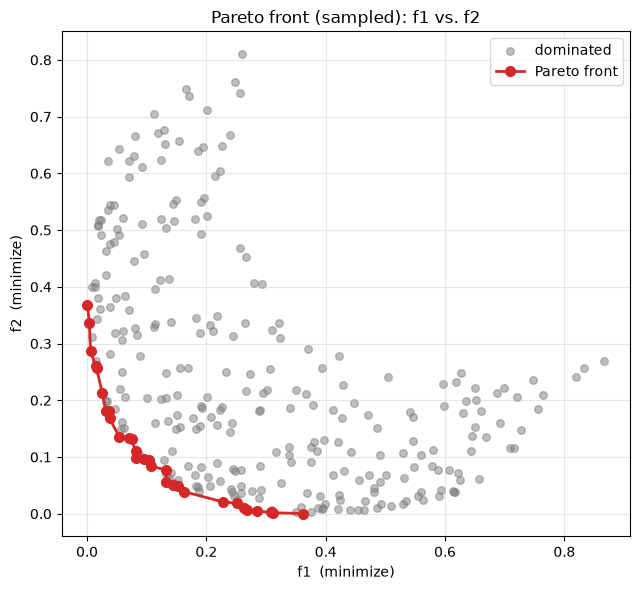

Pareto-optimal points: 30 of 300


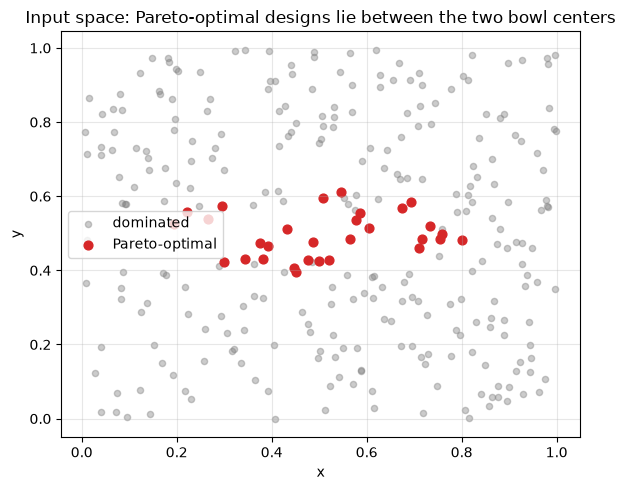

In [68]:
rng = np.random.default_rng(0)

def two_bowls_arr(X):
    x, y = X[:, 0], X[:, 1]
    f1 = (x - 0.2) ** 2 + (y - 0.5) ** 2
    f2 = (x - 0.8) ** 2 + (y - 0.5) ** 2
    return np.stack([f1, f2], axis=1)

Xs = rng.uniform(0, 1, size=(300, 2))
objs = two_bowls_arr(Xs)
mask = plot_pareto_2d(objs, title="Pareto front (sampled): f1 vs. f2")
print("Pareto-optimal points:", int(mask.sum()), "of", len(objs))

plt.figure(figsize=(6, 5))
plt.scatter(Xs[~mask, 0], Xs[~mask, 1], c="C7", alpha=0.4, s=20, label="dominated")
plt.scatter(Xs[mask, 0], Xs[mask, 1], c="C3", s=40, label="Pareto-optimal")
plt.xlabel("x"); plt.ylabel("y")
plt.title("Input space: Pareto-optimal designs lie between the two bowl centers")
plt.legend(loc="best"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Questions:** (1) why are dominated points up-and-right of the front? (2) describe the trade-off between two front points. (3) why do optimal designs lie between the bowl centers? (4) who picks the final point from the front?